# Deep Kernel GP Classification for Image Analysis


**Author:** Yongtao Liu  
**Date:** May 2026

## Installation

Make sure the package is installed:

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report,
    roc_curve,
    roc_auc_score
)
from engagegp.utils import get_grid_coords, get_subimages   # Image patch utilities

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

/Users/yla/ORNL Dropbox/Yongtao Liu/MyFiles/CNMS_2025/Githublocal/ENGAGEGP/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Import DKGP Classification
from engagegp import (
    DeepKernelGPClassifier,
    fit_dkgp_classifier,
    predict_classifier
)

In [3]:
import os
os.chdir('/Users/yla/Desktop/Mallory_Data')

(924, 924)


Text(0.5, 1.0, 'Label Image')

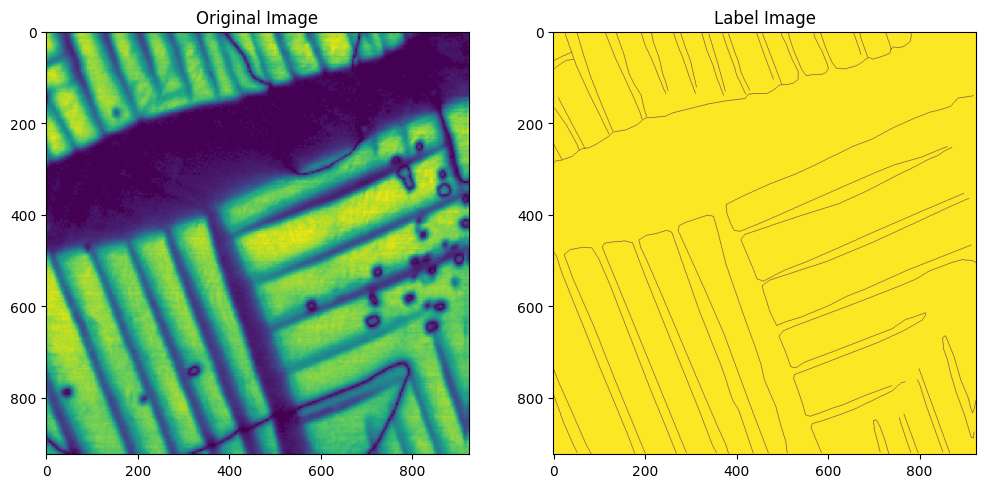

In [33]:
from PIL import Image

img = Image.open("BEPFM_volt05V_train_0002.tiff")
img_array = np.array(img)  # convert to numpy array
img_label = Image.open("BEPFM_volt05V_train_0002_dw.tif")
imglabel_array = np.array(img_label)  # convert to numpy array

print(img.size)
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(img_array, cmap='gray')
ax1.set_title('Original Image')
ax2.imshow(imglabel_array)
ax2.set_title('Label Image')

In [38]:
# Extract image patches centered at each pixel.
# These patches serve as the spatial context feature for the deep network.
import cv2

img = np.array(img)
img = cv2.resize (img, (256, 256))  # Downsample 
imglabel = np.array(img_label)
imglabel = cv2.resize (imglabel, (256, 256))  # Downsample
imglabel = (imglabel > 200).astype(int)  # Binarize labels

coordinates  = get_grid_coords(img, step=1)     # All (y, x) positions
window_size  = 20
    
patch_all, coords, _ = get_subimages(img, coordinates, window_size)
patch_all = patch_all[:, :, :, 0] 
label_all, coords, _ = get_subimages(imglabel, coordinates, window_size)
label_all = label_all[:, :, :, 0]       
coords       = np.array(coords, dtype=int)

print(f"Patches : {patch_all.shape}   (N, height, width)")
print(f"Labels  : {label_all.shape}   (N, height, width)")
print(f"Coords  : {coords.shape}         (N, 2)")

Patches : (56169, 20, 20)   (N, height, width)
Labels  : (56169, 20, 20)   (N, height, width)
Coords  : (56169, 2)         (N, 2)


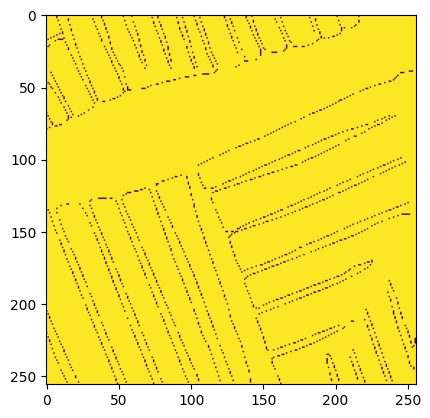

In [41]:
plt.imshow(imglabel)

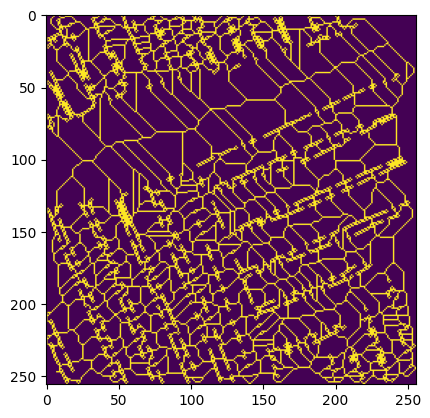

In [43]:
from skimage.morphology import skeletonize
from skimage import data
import matplotlib.pyplot as plt
from skimage.util import invert



# perform skeletonization
skeleton = skeletonize(imglabel)
plt.imshow(skeleton)

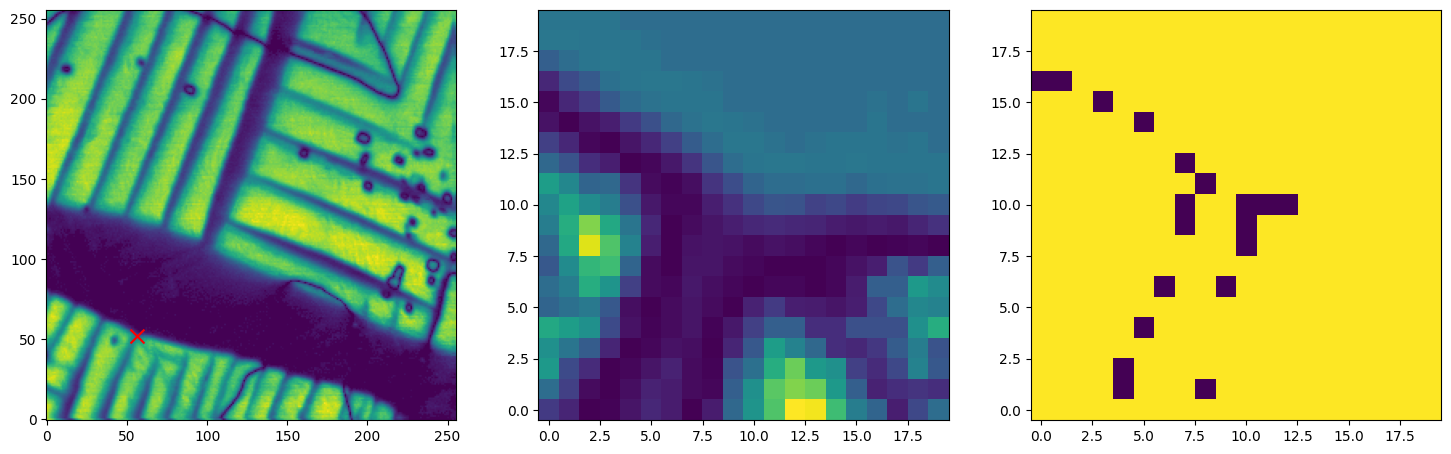

In [39]:
idx = 10000
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(img, cmap='gray', origin = 'lower')
ax1.scatter(coords[idx, 1], coords[idx, 0], color='red', s=100, marker='x')
ax2.imshow(patch_all[idx], origin = 'lower')
ax3.imshow(label_all[idx], origin = 'lower')

In [40]:
label_all[idx]

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 0, 1, 1, 1,

In [24]:
def is_domain_wall_patch(label_patch, center_radius=1, target_value=0):
    """
    Check whether a label-image patch contains a domain wall.

    Definition used here: a patch is a "domain wall" if the center pixel (odd-sized
    patch) or the central 2×2 block (even-sized patch), optionally expanded by
    `center_radius`, contains `background_value` (default 0).

    Parameters
    ----------
    label_patch : np.ndarray
        2D patch (H, W) or 3D patch (H, W, C). If 3D, the condition is applied
        per-pixel across channels (any channel equal to background counts as background).
    center_radius : int, default 0
        Expands the center region by this many pixels in all directions.
        For example, for a 24×24 patch and radius=0, the center region is 2×2;
        for radius=1 it becomes 4×4.
    target_value : int or float, default 0
        The value that indicates "domain wall" at the center (per your definition).

    Returns
    -------
    bool
        True if the (expanded) center region contains `target_value`.
    """
    patch = np.asarray(label_patch)
    if patch.ndim not in (2, 3):
        raise ValueError(f"label_patch must be 2D or 3D, got shape {patch.shape}")

    h, w = patch.shape[:2]
    if h == 0 or w == 0:
        raise ValueError("label_patch must be non-empty")

    r = int(center_radius)
    if r < 0:
        raise ValueError("center_radius must be >= 0")

    # Center region: 1x1 for odd, 2x2 for even (matches common "center" for even windows)
    y0 = (h - 1) // 2
    y1 = h // 2
    x0 = (w - 1) // 2
    x1 = w // 2

    y_start = max(0, y0 - r)
    y_stop = min(h, y1 + 1 + r)
    x_start = max(0, x0 - r)
    x_stop = min(w, x1 + 1 + r)

    center = patch[y_start:y_stop, x_start:x_stop]
    if patch.ndim == 3:
        is_target = np.any(center == target_value, axis=-1)
    else:
        is_target = center == target_value
    return bool(np.any(is_target))

In [26]:
is_domain_wall_patch(label_all[idx], center_radius=2, target_value=1)

False

In [18]:
y_all = []
for i in range(len(label_all)):
    y_all.append(is_domain_wall_patch(label_all[i], center_radius=2, target_value=0))
y_all = np.array(y_all)

is domain wall patch? False


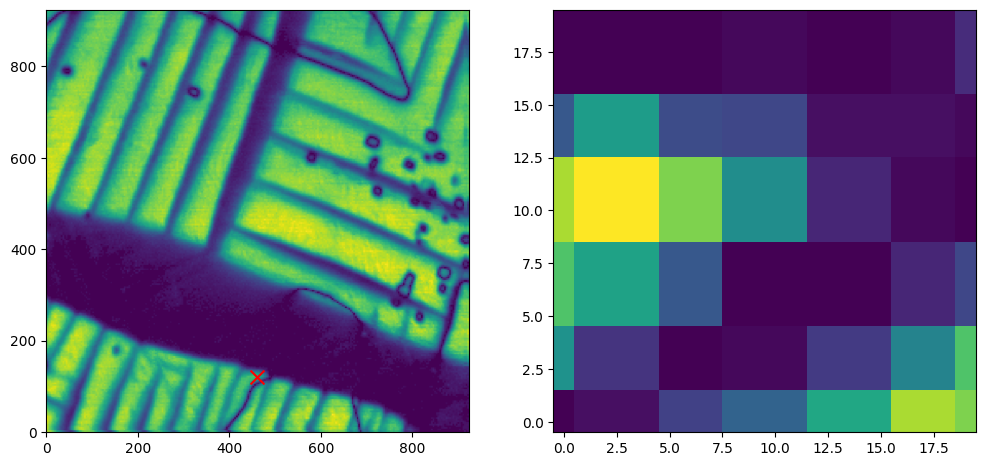

In [21]:
idx = 100000
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(img, cmap='gray', origin = 'lower')
ax1.scatter(coords[idx, 1], coords[idx, 0], color='red', s=100, marker='x')
ax2.imshow(patch_all[idx], origin = 'lower')
print(f"is domain wall patch? {y_all[idx]}")

---
## Binary Classification: Moons Dataset

Let's start with a classic non-linearly separable dataset.

### Generate Dataset

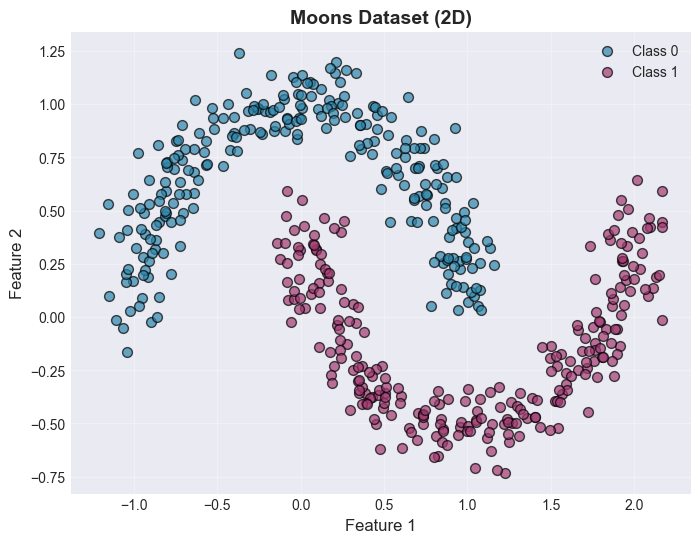

Dataset shape: (500, 2)
Class distribution: [250 250]


In [5]:
# Generate moons dataset (2D)
X_2d, y_binary = make_moons(n_samples=500, noise=0.1, random_state=42)

# Visualize 2D data
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[y_binary==0, 0], X_2d[y_binary==0, 1], 
           c='#2E86AB', s=50, alpha=0.7, edgecolors='k', label='Class 0')
plt.scatter(X_2d[y_binary==1, 0], X_2d[y_binary==1, 1], 
           c='#A23B72', s=50, alpha=0.7, edgecolors='k', label='Class 1')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Moons Dataset (2D)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset shape: {X_2d.shape}")
print(f"Class distribution: {np.bincount(y_binary)}")

In [6]:
# Add extra dimensions to make it high-dimensional
# This simulates real-world scenarios with many features
n_extra_dims = 48
X_binary = np.hstack([X_2d, np.random.randn(500, n_extra_dims)])

print(f"High-dimensional dataset shape: {X_binary.shape}")
print(f"Total features: {X_binary.shape[1]} (2 informative + {n_extra_dims} noise)")

High-dimensional dataset shape: (500, 50)
Total features: 50 (2 informative + 48 noise)


In [7]:
# Split into train and test sets
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

print(f"Training set: {X_train_bin.shape}")
print(f"Test set: {X_test_bin.shape}")
print(f"Training class distribution: {np.bincount(y_train_bin)}")
print(f"Test class distribution: {np.bincount(y_test_bin)}")

Training set: (350, 50)
Test set: (150, 50)
Training class distribution: [175 175]
Test class distribution: [75 75]


### Train Binary Classifier

Training Deep Kernel GP Classifier
Feature Extractor: attention

Auto-selected: VariationalELBO

Training Deep Kernel GP Classifier
  Device: cpu
  Extractor type: attention
  Input dim: 50 → Feature dim: 8
  Classes: 2
  Samples: 350
  Inducing points: 100
  ELBO: VariationalELBO
  Epoch  100/2000, Loss: 0.0902
  Epoch  200/2000, Loss: 0.0455
  Epoch  300/2000, Loss: 0.0373
  Epoch  400/2000, Loss: 0.0331
  Epoch  500/2000, Loss: 0.0304
  Epoch  600/2000, Loss: 0.0283
  Epoch  700/2000, Loss: 0.0255
  Epoch  800/2000, Loss: 0.0242
  Epoch  900/2000, Loss: 0.0231
  Epoch 1000/2000, Loss: 0.0223
  Epoch 1100/2000, Loss: 0.0215
  Epoch 1200/2000, Loss: 0.0209
  Epoch 1300/2000, Loss: 0.0204
  Epoch 1400/2000, Loss: 0.0199
  Epoch 1500/2000, Loss: 0.0195
  Epoch 1600/2000, Loss: 0.0192
  Epoch 1700/2000, Loss: 0.0189
  Epoch 1800/2000, Loss: 0.0186
  Epoch 1900/2000, Loss: 0.0183
  Epoch 2000/2000, Loss: 0.0181
Training complete! Final loss: 0.0181


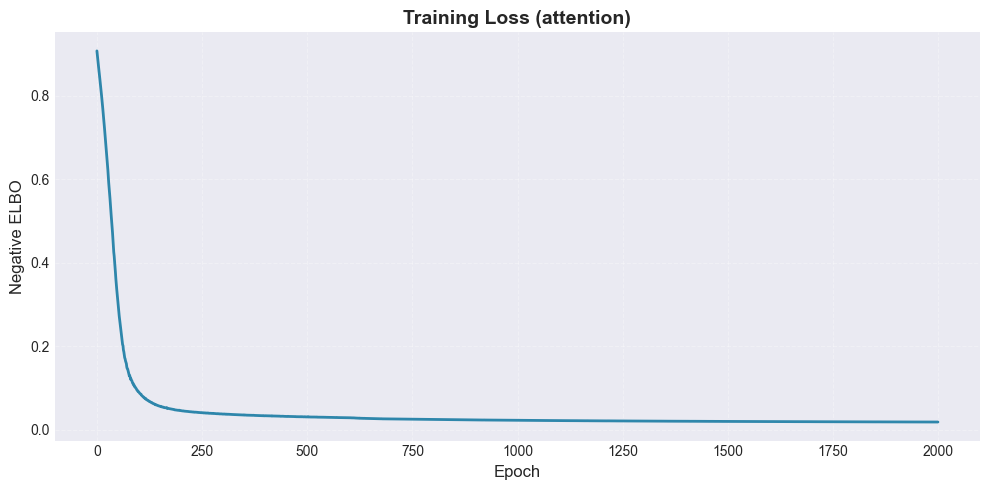

In [8]:
# Train the classifier
model_binary, losses_binary = fit_dkgp_classifier(
    X_train_bin,
    y_train_bin,
    num_classes=2,           # Binary classification
    feature_dim=8,           # Reduce 100D -> 16D
    extractor_type = 'attention',    # Fully connected extractor
    num_epochs=2000,          # Training iterations
    verbose=True 
)

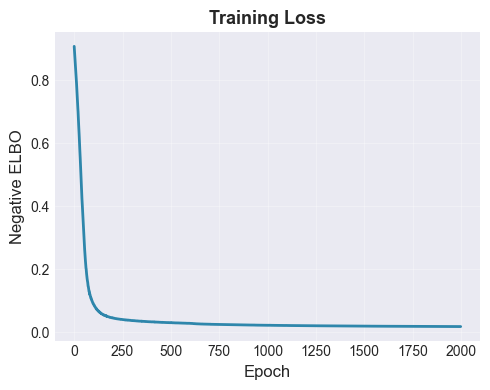

Final training loss: 0.0181


In [9]:
# Plot training loss
plt.figure(figsize=(5, 4))

plt.plot(losses_binary, linewidth=2, color='#2E86AB')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Negative ELBO', fontsize=12)
plt.title('Training Loss', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final training loss: {losses_binary[-1]:.4f}")

### Make Predictions

In [10]:
# Predict class labels
y_pred_bin = predict_classifier(model_binary, X_test_bin)

# Predict class probabilities
y_proba_bin = predict_classifier(model_binary, X_test_bin, return_proba=True)

print(f"Predictions shape: {y_pred_bin.shape}")
print(f"Probabilities shape: {y_proba_bin.shape}")
print(f"\nFirst 5 predictions:")
print(f"  True:  {y_test_bin[:5]}")
print(f"  Pred:  {y_pred_bin[:5]}")
print(f"  Prob Class 0: {y_proba_bin[:5, 0]}")
print(f"  Prob Class 1: {y_proba_bin[:5, 1]}")

Predictions shape: (150,)
Probabilities shape: (150, 2)

First 5 predictions:
  True:  [1 1 0 0 1]
  Pred:  [1 1 0 1 1]
  Prob Class 0: [0.05330795 0.03145844 0.669178   0.35179496 0.02944058]
  Prob Class 1: [0.94669205 0.96854156 0.33082202 0.64820504 0.9705594 ]


### Evaluate Performance

In [10]:
# Compute metrics
accuracy = accuracy_score(y_test_bin, y_pred_bin)
precision = precision_score(y_test_bin, y_pred_bin)
recall = recall_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

# Average confidence
confidence = y_proba_bin.max(axis=1).mean()

print("Binary Classification Results")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Avg Confidence: {confidence:.4f}")
print("=" * 40)

Binary Classification Results
Accuracy:  0.7467
Precision: 0.7467
Recall:    0.7467
F1 Score:  0.7467
Avg Confidence: 0.8627


In [11]:
# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Class 0', 'Class 1']))


Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.75      0.75      0.75        75
     Class 1       0.75      0.75      0.75        75

    accuracy                           0.75       150
   macro avg       0.75      0.75      0.75       150
weighted avg       0.75      0.75      0.75       150



### Visualize Results

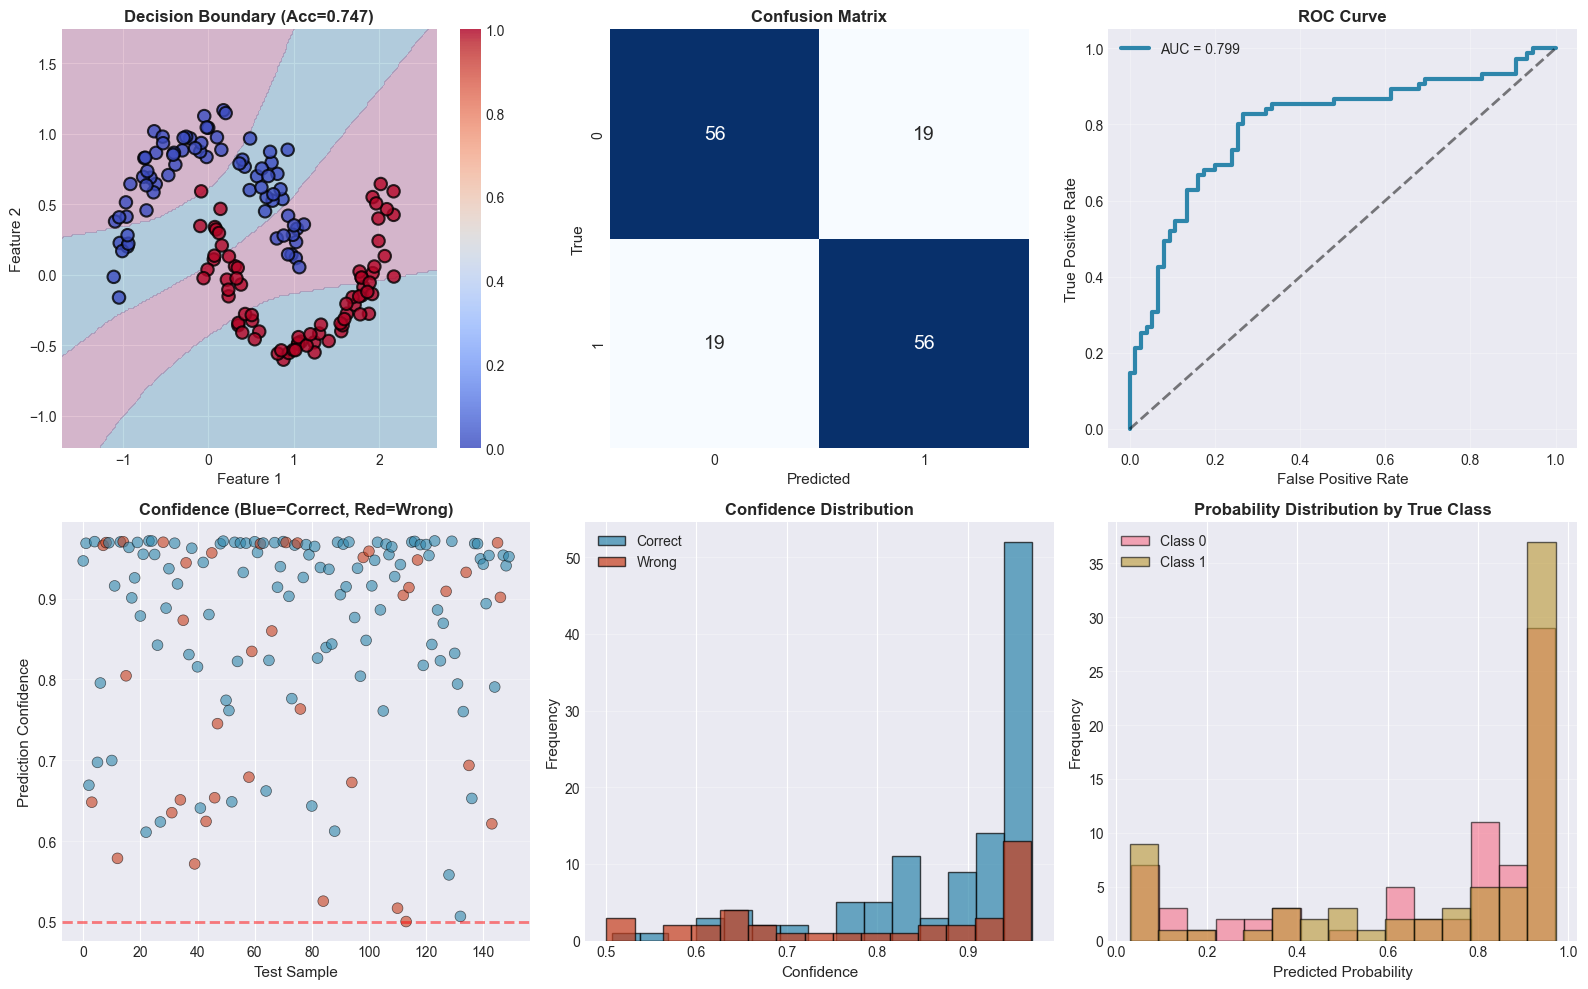

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Decision boundary (2D projection)
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
mesh_2d = np.c_[xx.ravel(), yy.ravel()]
mesh_high = np.hstack([mesh_2d, np.zeros((len(mesh_2d), n_extra_dims))])
Z = predict_classifier(model_binary, mesh_high)
Z = Z.reshape(xx.shape)

axes[0, 0].contourf(xx, yy, Z, alpha=0.3, levels=1, colors=['#2E86AB', '#A23B72'])
scatter = axes[0, 0].scatter(X_test_bin[:, 0], X_test_bin[:, 1], 
                            c=y_test_bin, s=80, edgecolors='k', 
                            linewidth=1.5, cmap='coolwarm', alpha=0.8)
axes[0, 0].set_xlabel('Feature 1', fontsize=11)
axes[0, 0].set_ylabel('Feature 2', fontsize=11)
axes[0, 0].set_title(f'Decision Boundary (Acc={accuracy:.3f})', 
                    fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0])

# 2. Confusion Matrix
cm = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
           cbar=False, square=True, annot_kws={'size': 14})
axes[0, 1].set_xlabel('Predicted', fontsize=11)
axes[0, 1].set_ylabel('True', fontsize=11)
axes[0, 1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test_bin, y_proba_bin[:, 1])
auc = roc_auc_score(y_test_bin, y_proba_bin[:, 1])
axes[0, 2].plot(fpr, tpr, linewidth=3, label=f'AUC = {auc:.3f}', color='#2E86AB')
axes[0, 2].plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5)
axes[0, 2].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 2].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 2].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# 4. Prediction Confidence
confidence_scores = y_proba_bin.max(axis=1)
correct = y_test_bin == y_pred_bin
colors = ['#2E86AB' if c else '#C73E1D' for c in correct]
axes[1, 0].scatter(range(len(confidence_scores)), confidence_scores,
                  c=colors, s=60, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[1, 0].axhline(y=0.5, color='r', linestyle='--', linewidth=2, alpha=0.5)
axes[1, 0].set_xlabel('Test Sample', fontsize=11)
axes[1, 0].set_ylabel('Prediction Confidence', fontsize=11)
axes[1, 0].set_title('Confidence (Blue=Correct, Red=Wrong)', 
                    fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Confidence Distribution
axes[1, 1].hist(confidence_scores[correct], bins=15, alpha=0.7, 
               label='Correct', color='#2E86AB', edgecolor='k')
axes[1, 1].hist(confidence_scores[~correct], bins=15, alpha=0.7, 
               label='Wrong', color='#C73E1D', edgecolor='k')
axes[1, 1].set_xlabel('Confidence', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Confidence Distribution', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Class Probabilities
for i in range(2):
    class_probs = y_proba_bin[y_test_bin == i, i]
    axes[1, 2].hist(class_probs, bins=15, alpha=0.6, 
                   label=f'Class {i}', edgecolor='k')
axes[1, 2].set_xlabel('Predicted Probability', fontsize=11)
axes[1, 2].set_ylabel('Frequency', fontsize=11)
axes[1, 2].set_title('Probability Distribution by True Class', 
                    fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Uncertainty Analysis

In [13]:
# Analyze uncertainty
uncertainty = 1 - confidence_scores  # Uncertainty = 1 - max probability

# Find most confident and uncertain predictions
most_confident_idx = np.argsort(confidence_scores)[-5:][::-1]
most_uncertain_idx = np.argsort(confidence_scores)[:5]

print("Most Confident Predictions:")
print("=" * 50)
for idx in most_confident_idx:
    print(f"Sample {idx}: True={y_test_bin[idx]}, Pred={y_pred_bin[idx]}, "
          f"Confidence={confidence_scores[idx]:.4f}")

print("\nMost Uncertain Predictions:")
print("=" * 50)
for idx in most_uncertain_idx:
    print(f"Sample {idx}: True={y_test_bin[idx]}, Pred={y_pred_bin[idx]}, "
          f"Confidence={confidence_scores[idx]:.4f}")

Most Confident Predictions:
Sample 123: True=1, Pred=1, Confidence=0.9714
Sample 23: True=1, Pred=1, Confidence=0.9714
Sample 24: True=0, Pred=0, Confidence=0.9713
Sample 49: True=1, Pred=1, Confidence=0.9712
Sample 129: True=0, Pred=0, Confidence=0.9710

Most Uncertain Predictions:
Sample 113: True=1, Pred=0, Confidence=0.5005
Sample 132: True=1, Pred=1, Confidence=0.5069
Sample 110: True=0, Pred=1, Confidence=0.5170
Sample 84: True=1, Pred=0, Confidence=0.5258
Sample 128: True=1, Pred=1, Confidence=0.5583


---
## Multi-Class Classification

Now let's tackle a 4-class classification problem.

### Generate Multi-Class Dataset

In [11]:
# Generate synthetic multi-class data
X_multi, y_multi = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=2,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=0.8,
    random_state=42
)

# Add more dimensions
X_multi = np.hstack([X_multi, np.random.randn(1000, 30)])

print(f"Multi-class dataset shape: {X_multi.shape}")
print(f"Number of classes: {len(np.unique(y_multi))}")
print(f"Class distribution: {np.bincount(y_multi)}")

Multi-class dataset shape: (1000, 35)
Number of classes: 4
Class distribution: [253 249 252 246]


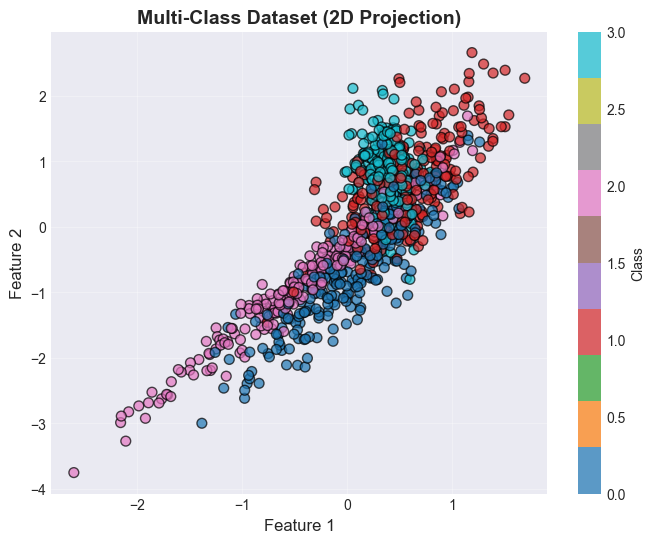

In [12]:
# Visualize first 2 dimensions
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_multi[:, 0], X_multi[:, 1], c=y_multi, 
                     s=50, alpha=0.7, edgecolors='k', cmap='tab10')
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('Multi-Class Dataset (2D Projection)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Class')
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.5, random_state=42, stratify=y_multi
)

print(f"Training set: {X_train_m.shape}")
print(f"Test set: {X_test_m.shape}")
print(f"Training class distribution: {np.bincount(y_train_m)}")
print(f"Test class distribution: {np.bincount(y_test_m)}")

Training set: (500, 35)
Test set: (500, 35)
Training class distribution: [126 125 126 123]
Test class distribution: [127 124 126 123]


### Train Multi-Class Classifier

In [19]:
# Train multi-class classifier
model_multi, losses_multi = fit_dkgp_classifier(
    X_train_m,
    y_train_m,
    num_classes=4,           # 4 classes
    extractor_type = 'attention',    # Attention-based extractor
    feature_dim=16,
    hidden_dims=[256, 128, 64],
    num_inducing=100,        # More inducing points for multi-class
    num_epochs=2000,
    lr_features=1e-4,
    lr_gp=1e-2,
    verbose=True,
    plot_loss=False
)

Training Deep Kernel GP Classifier
Feature Extractor: attention

Auto-selected: VariationalELBO

Training Deep Kernel GP Classifier
  Device: cpu
  Extractor type: attention
  Input dim: 35 → Feature dim: 16
  Classes: 4
  Samples: 500
  Inducing points: 100
  ELBO: VariationalELBO
  Epoch  100/2000, Loss: 0.9886
  Epoch  200/2000, Loss: 0.2391
  Epoch  300/2000, Loss: 0.1661
  Epoch  400/2000, Loss: 0.1312
  Epoch  500/2000, Loss: 0.1101
  Epoch  600/2000, Loss: 0.0983
  Epoch  700/2000, Loss: 0.0884
  Epoch  800/2000, Loss: 0.0827
  Epoch  900/2000, Loss: 0.0768
  Epoch 1000/2000, Loss: 0.0724
  Epoch 1100/2000, Loss: 0.0689
  Epoch 1200/2000, Loss: 0.0656
  Epoch 1300/2000, Loss: 0.0629
  Epoch 1400/2000, Loss: 0.0608
  Epoch 1500/2000, Loss: 0.0581
  Epoch 1600/2000, Loss: 0.0570
  Epoch 1700/2000, Loss: 0.0554
  Epoch 1800/2000, Loss: 0.0538
  Epoch 1900/2000, Loss: 0.0523
  Epoch 2000/2000, Loss: 0.0504
Training complete! Final loss: 0.0504


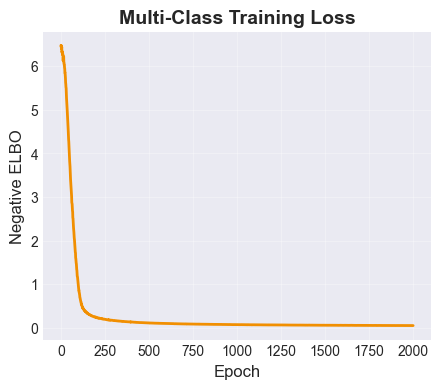

Final training loss: 0.0504


In [20]:
# Plot training loss
plt.figure(figsize=(5, 4))
plt.plot(losses_multi, linewidth=2, color='#F18F01')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Negative ELBO', fontsize=12)
plt.title('Multi-Class Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final training loss: {losses_multi[-1]:.4f}")

### Evaluate Multi-Class Model

In [21]:
# Predictions
y_pred_m = predict_classifier(model_multi, X_test_m)
y_proba_m = predict_classifier(model_multi, X_test_m, return_proba=True)

# Compute metrics
accuracy_m = accuracy_score(y_test_m, y_pred_m)
precision_m = precision_score(y_test_m, y_pred_m, average='weighted')
recall_m = recall_score(y_test_m, y_pred_m, average='weighted')
f1_m = f1_score(y_test_m, y_pred_m, average='weighted')

print("Multi-Class Classification Results")
print("=" * 40)
print(f"Accuracy:  {accuracy_m:.4f}")
print(f"Precision: {precision_m:.4f}")
print(f"Recall:    {recall_m:.4f}")
print(f"F1 Score:  {f1_m:.4f}")
print(f"Avg Confidence: {y_proba_m.max(axis=1).mean():.4f}")
print("=" * 40)

Multi-Class Classification Results
Accuracy:  0.5800
Precision: 0.5797
Recall:    0.5800
F1 Score:  0.5793
Avg Confidence: 0.8668


In [22]:
# Detailed report
print("\nDetailed Classification Report:")
print(classification_report(y_test_m, y_pred_m, 
                          target_names=[f'Class {i}' for i in range(4)]))


Detailed Classification Report:
              precision    recall  f1-score   support

     Class 0       0.59      0.65      0.62       127
     Class 1       0.48      0.45      0.46       124
     Class 2       0.58      0.60      0.59       126
     Class 3       0.67      0.63      0.65       123

    accuracy                           0.58       500
   macro avg       0.58      0.58      0.58       500
weighted avg       0.58      0.58      0.58       500



### Visualize Multi-Class Results

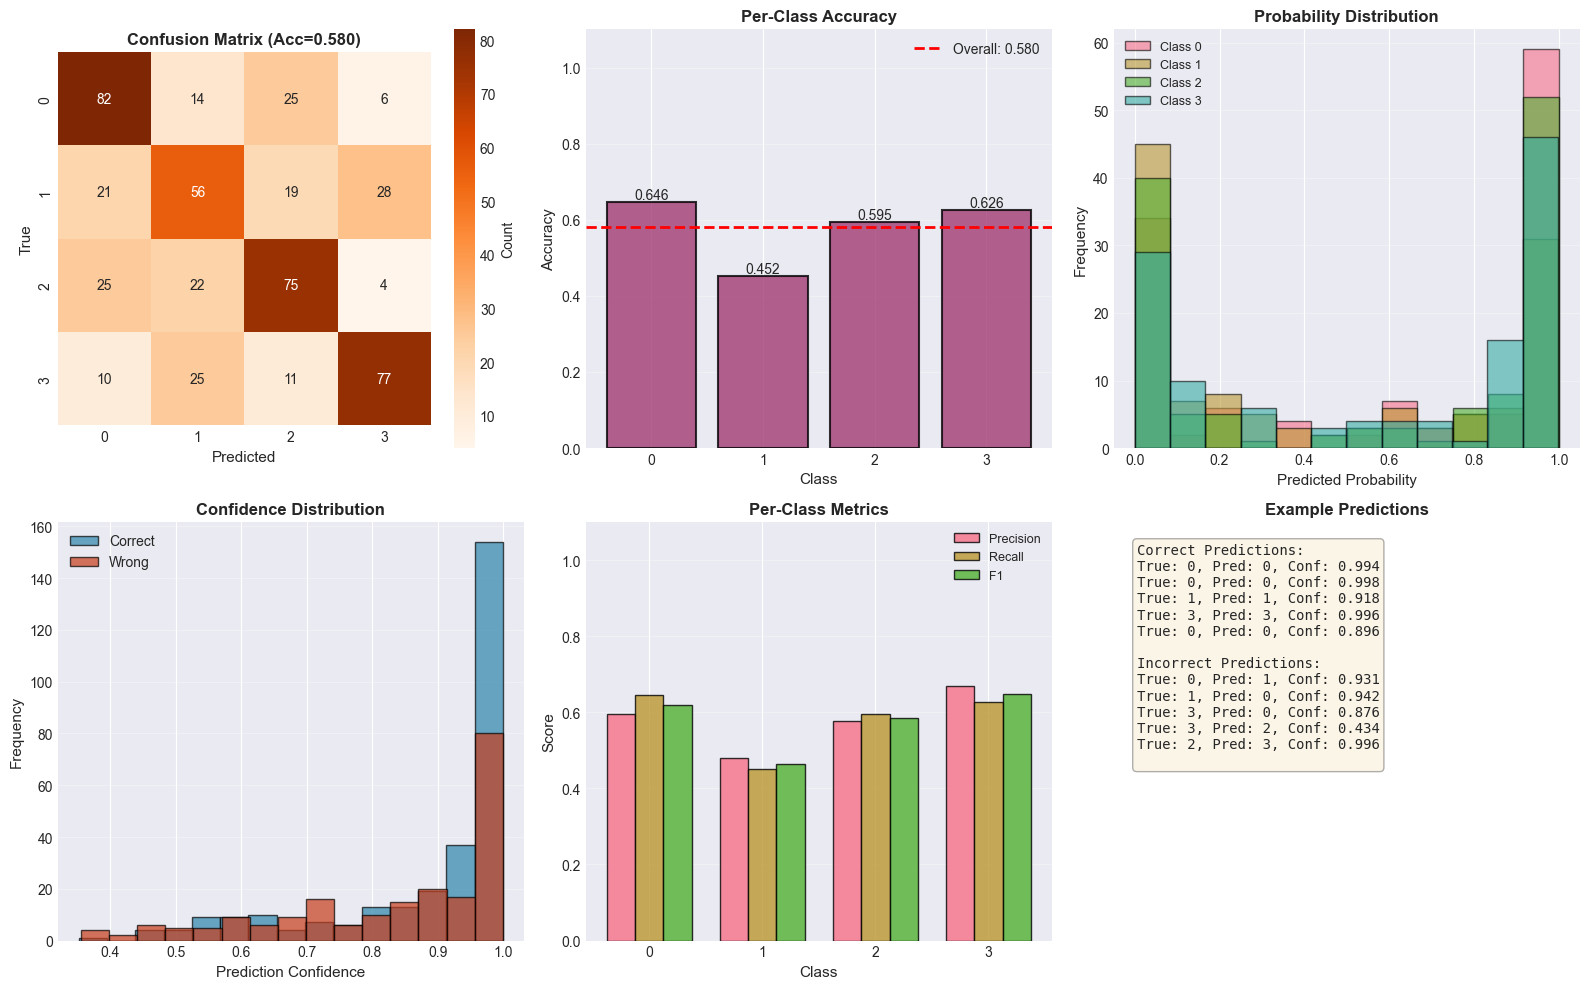

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix
cm_m = confusion_matrix(y_test_m, y_pred_m)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 0],
           square=True, cbar_kws={'label': 'Count'})
axes[0, 0].set_xlabel('Predicted', fontsize=11)
axes[0, 0].set_ylabel('True', fontsize=11)
axes[0, 0].set_title(f'Confusion Matrix (Acc={accuracy_m:.3f})', 
                    fontsize=12, fontweight='bold')

# 2. Per-Class Accuracy
per_class_acc = []
for i in range(4):
    mask = y_test_m == i
    acc_i = (y_test_m[mask] == y_pred_m[mask]).mean() if mask.sum() > 0 else 0
    per_class_acc.append(acc_i)

bars = axes[0, 1].bar(range(4), per_class_acc, color='#A23B72', 
                     alpha=0.8, edgecolor='k', linewidth=1.5)
axes[0, 1].axhline(y=accuracy_m, color='r', linestyle='--', 
                  linewidth=2, label=f'Overall: {accuracy_m:.3f}')
axes[0, 1].set_xlabel('Class', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Per-Class Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1.1])
axes[0, 1].set_xticks(range(4))
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{per_class_acc[i]:.3f}',
                   ha='center', va='bottom', fontsize=10)

# 3. Probability Distribution by True Class
for i in range(4):
    class_probs = y_proba_m[y_test_m == i, i]
    axes[0, 2].hist(class_probs, bins=12, alpha=0.6, 
                   label=f'Class {i}', edgecolor='k')
axes[0, 2].set_xlabel('Predicted Probability', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('Probability Distribution', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Confidence by Correctness
confidence_m = y_proba_m.max(axis=1)
correct_m = y_test_m == y_pred_m
axes[1, 0].hist(confidence_m[correct_m], bins=15, alpha=0.7, 
               label='Correct', color='#2E86AB', edgecolor='k')
axes[1, 0].hist(confidence_m[~correct_m], bins=15, alpha=0.7, 
               label='Wrong', color='#C73E1D', edgecolor='k')
axes[1, 0].set_xlabel('Prediction Confidence', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Confidence Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Per-Class Precision, Recall, F1
metrics_per_class = []
for i in range(4):
    precision_i = precision_score(y_test_m == i, y_pred_m == i, zero_division=0)
    recall_i = recall_score(y_test_m == i, y_pred_m == i, zero_division=0)
    f1_i = f1_score(y_test_m == i, y_pred_m == i, zero_division=0)
    metrics_per_class.append([precision_i, recall_i, f1_i])

metrics_per_class = np.array(metrics_per_class)
x = np.arange(4)
width = 0.25
axes[1, 1].bar(x - width, metrics_per_class[:, 0], width, 
              label='Precision', alpha=0.8, edgecolor='k')
axes[1, 1].bar(x, metrics_per_class[:, 1], width, 
              label='Recall', alpha=0.8, edgecolor='k')
axes[1, 1].bar(x + width, metrics_per_class[:, 2], width, 
              label='F1', alpha=0.8, edgecolor='k')
axes[1, 1].set_xlabel('Class', fontsize=11)
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_title('Per-Class Metrics', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Prediction Examples
# Show some correct and incorrect predictions
correct_idx = np.where(correct_m)[0][:5]
wrong_idx = np.where(~correct_m)[0][:5]

example_text = "Correct Predictions:\n"
for idx in correct_idx:
    example_text += f"True: {y_test_m[idx]}, Pred: {y_pred_m[idx]}, "
    example_text += f"Conf: {confidence_m[idx]:.3f}\n"

example_text += "\nIncorrect Predictions:\n"
for idx in wrong_idx:
    example_text += f"True: {y_test_m[idx]}, Pred: {y_pred_m[idx]}, "
    example_text += f"Conf: {confidence_m[idx]:.3f}\n"

axes[1, 2].text(0.05, 0.95, example_text, transform=axes[1, 2].transAxes,
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 2].set_title('Example Predictions', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

---
## Comparison: Binary vs Multi-Class

In [34]:
# Create comparison table
import pandas as pd

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Avg Confidence'],
    'Binary': [accuracy, precision, recall, f1, confidence],
    'Multi-Class': [accuracy_m, precision_m, recall_m, f1_m, y_proba_m.max(axis=1).mean()]
})

print("\nPerformance Comparison")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)


Performance Comparison
        Metric   Binary  Multi-Class
      Accuracy 0.780000     0.868000
     Precision 0.769231     0.870775
        Recall 0.800000     0.868000
      F1 Score 0.784314     0.868135
Avg Confidence 0.898986     0.912284


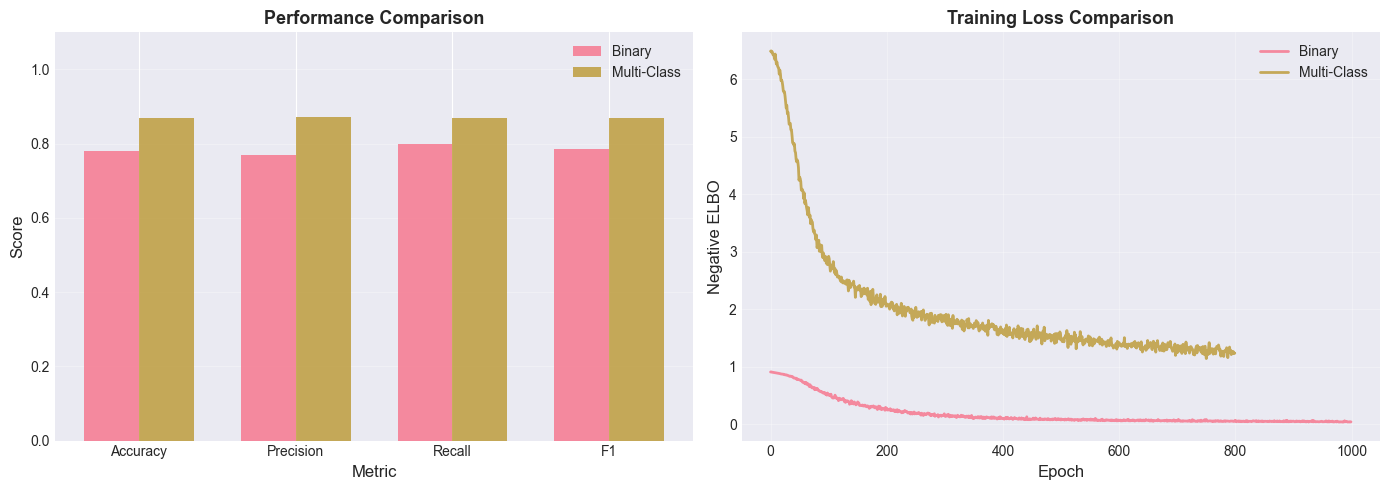

In [35]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
binary_scores = [accuracy, precision, recall, f1]
multi_scores = [accuracy_m, precision_m, recall_m, f1_m]

x = np.arange(len(metrics))
width = 0.35
axes[0].bar(x - width/2, binary_scores, width, label='Binary', alpha=0.8)
axes[0].bar(x + width/2, multi_scores, width, label='Multi-Class', alpha=0.8)
axes[0].set_xlabel('Metric', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Performance Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim([0, 1.1])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Training loss comparison
axes[1].plot(losses_binary, label='Binary', linewidth=2, alpha=0.8)
axes[1].plot(losses_multi, label='Multi-Class', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Negative ELBO', fontsize=12)
axes[1].set_title('Training Loss Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()